# Digital Image Processing in Python

## Preface

In order to digitally process images using Python, begin by importing the necessary libraries:
>- **`numpy`** : Numerical computation
>- **`cv2`** : Image processing
>- **`matplotlib.pyplot`** : Visualization

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

#### Reading an image with OpenCV

The following file types are supported by the OpenCV library:
>* Windows bitmaps —> `*.bmp`, `*.dib`
>* JPEG —> `*.jpeg`, `*.jpg`
>* Portable Network Graphics —> `*.png`
>* WebP —> `*.webp`
>* Sun rasters —> `*.sr`, `*.ras`
>* TIFF —> `*.tiff`, `*.tif`
>* Raster and Vector geospatial data supported by GDAL

The steps to read and display an image in Python using OpenCV are as follows:
1. Read an image using the `imread()` function
2. Create a GUI window and display the image using the `imshow()` function
3. Use the function `waitkey(0)` to hold the image window on the screen by the specified number of seconds (`0` means until the user closes the window)
4. Delete the image window from memory after following display using the `destroyAllWindows()` function

If the image cannot be read (due to, say, a missing file, improper permissions, or unsupported/invalid format) then the `imread()` function returns an empty matrix.

>***Syntax*:** 
>>```python
>>cv2.imread(path, flag)
>>```

>***Parameters*:**
>>**`path`:** A string representing the path of the image to be read
>>
>>**`flag`:** Specifies the manner in which the image is read. The default value is `cv2.IMREAD_COLOR`

>***Return Value*:**
>>This message returns an image that is loaded from the specified file

There are a few ideas to note at this stage. For one, the image should be in the working directory, and, if not, the full path to the image must be given. Second, OpenCV stored colored images in BGR (blue, green, red) format by default. This point is particularly important since the naive is accustomed to RGB formats.

Three distinct flags can be passed to the `imread()` function, and are as follows:
>```python
>cv2.IMREAD_COLOR
>```
>>Specifies to load a BGR color image. Any transparency (alpha channel) will be neglected. Default flag; alternatively, we can pass `1` for this flag.

>```python
>cv2.IMREAD_GRAYSCALE
>```
>>Specifies to load a grayscale image. Alternatively, we can pass `0` for this flag.

>```python
>cv2.IMREAD_UNCHANGED
>```
>>Specifies to load an image "*as is*," including the alpha channel. Alternatively, we can pass `-1` for this flag.

In [5]:
img = cv2.imread("/Users/elij/Desktop/Imagery/di-img/oxpecker-impala.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

---

## Preprocessing

Here is an example that loads an image and simulates a filtered version (e.g., blurred + noisy) as the observed input $y\dots$
>*Variables*:
>>`original`:
>>- The grayscale image loaded as the starting point
>>- Normalized to a range of [0, 1] to simplify mathematical operations
>
>>`motion_blur`:
>>- A kernel (small matrix) used for convolution to simulate a blur
>>- Represents the "filter" $f(\cdot)$ that modifies the original image
>>- Constructed using Gaussian or other mathematical forms
>
>>`filtered`:
>>- The output of applying $f(\cdot)$ (via convolution) to `original`
>>- Represents the clean version of the filtered image
>
>>`noisy_filtered`:
>>- The filtered image after adding random noise
>>- Represents a real world scenario where noise obscures details

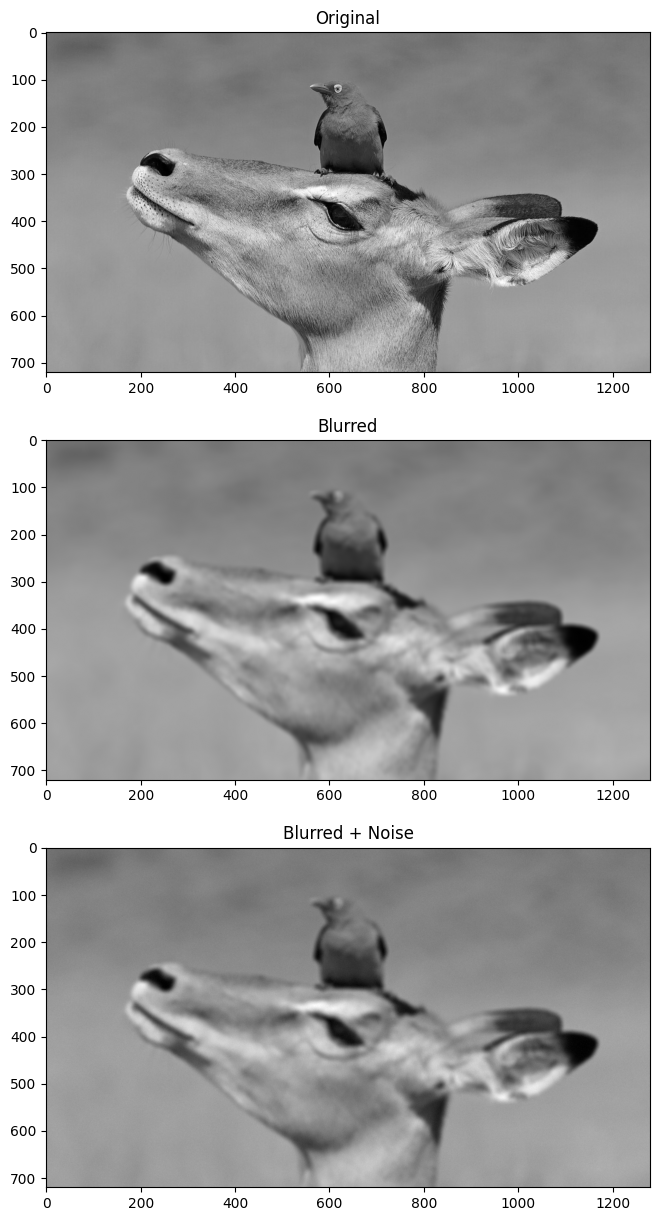

In [6]:
# Load the image
original = cv2.imread("/Users/elij/Desktop/Imagery/di-img/oxpecker-impala.jpg", cv2.IMREAD_GRAYSCALE) / 255.0  # Normalize to [0, 1]

# Simulate a filter (e.g., motion blur + noise)
kernel = cv2.getGaussianKernel(ksize=15, sigma=5)
motion_blur = np.outer(kernel, kernel)  # Create a blur kernel
filtered = cv2.filter2D(original, -1, motion_blur)

# Add Gaussian noise
noise = np.random.normal(0, 0.01, filtered.shape)
noisy_filtered = np.clip(filtered + noise, 0, 1)

# Visualize
plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1); plt.title("Original"); plt.imshow(original, cmap='gray')
plt.subplot(3, 1, 2); plt.title("Blurred"); plt.imshow(filtered, cmap='gray')
plt.subplot(3, 1, 3); plt.title("Blurred + Noise"); plt.imshow(noisy_filtered, cmap='gray')
plt.show()

---

## Geometric Transformations of Images

OpenCV provides two transformation functions that permit all kinds of image transformations. These are **`cv.warpAffine`** and **`cv.warpPerspective`**; the former takes a 2$\times$3 transformation matrix, while the latter takes a 3$\times$3 transformation matrix as input.

```python
1   cv2.warpAffine()
```

The steps to apply an affine transformation to an image in Python using OpenCV's `cv2.warpAffine()` function are as follows:
1. Define or calculate a 2$\times$3 transformation matrix `M`. This matrix can describe rotations, translations, scaling, or shearing.
2. Specify the desired output image size (`dsize`) as `(width, height)`.
3. Choose an interpolation method (e.g., `cv2.INTER_LINEAR`) and a border mode (e.g., `cv2.BORDER_CONSTANT`) as needed.
4. Call the `warpAffine()` function with the source image, the transformation matrix, and additional parameters to produced the transformed output.

If the transformation matrix or the source image is set improperly (e.g., wrong dimensions, invalid size), the resulting output may appear distorted or empty. One should verify that the transformation matrix corresponds correctly to the intended operation (e.g., rotation, translation) and that the `dsize` is large enough to contain the transformed image.

>***Syntax***:
>>```python
>>cv2.warpAffine(src, M, dsize[, flags[, borderMode[, borderValue]]]) -> dst
>>```
>
>***Parameters***:
>>**`src`**
>>
>>The source image on which the transformation is to be applied (e.g., a NumPy array)
>
>>**`M`**
>>
>>A 2$\times$3 affine transformation matrix that specifies how points in the `src` map to points in the output
>
>>**`dsize`**
>>
>>Size of the output image in the form `(width, height)`
>
>>**`flags` (optional)**
>>
>>Specifies interpolation and optional `WARP_INVERSE_MAP`. Common options include:
>>- `cv2.INTER_LINEAR` (default; bilinear interpolation)
>>- `cv2.INTER_NEAREST` (fastest but less smooth)
>>- `cv2.INTER_CUBIC` (slower but higher-quality)
>
>>**`borderMode` (optional)**
>>
>>Defines how to handle pixels that appear outside the image boundary. For instance:
>>- `cv2.BORDER_CONSTANT` (fill with `borderValue`)
>>- `cv2.BORDER_REPLICATE` (repeat the edge pixels)
>
>>**`borderValue` (optional)**
>>
>>Used when `borderMode=cv2.BORDER_CONSTANT`; specifies the fill color (default is *0*)
>
>***Return Value***:
>>*Returns the transformed image* (`dst`), which is a new array reflecting the applied affine transformation.

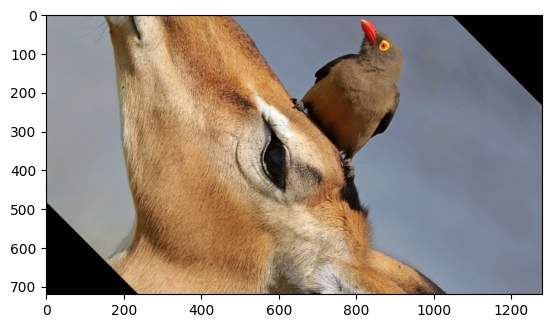

In [7]:
(height, width) = img.shape[:2]
center = (width // 2, height // 2)

# e.g., rotate by 45 degrees, scale=1.0
M = cv2.getRotationMatrix2D(center, 315, 1.5)

rotated = cv2.warpAffine(img, M, (width, height))

plt.imshow(rotated); plt.show()

## Reverse Image Filtering

### ✳︎ Landweber iterations

The **Landweber iteration** algorithm iteratively refines the estimate of $x$ (original image) based on the residual error. The update rule is:
$$
X_{k+1} = X_{k} - \tau H^*(HX_{k} - Y)
$$
Here, $H$ is the filter (e.g., motion blur), and $H^*$ is its adjoint (transpose).
>*Arguments*:
>>`y`:
>>- The observed filtered image (e.g., `noisy_filtered`)
>>- Treated as the "known" output that we are trying to reverse-engineer to recover the original image
>
>>`filter_kernel`:
>>- The kernel that represents the filtering operation (e.g., motion blur or Gaussian blur)
>>- Used for forward and backward passes during iteration
>
>>`tau`:
>>- The step size controlling how much adjustment is made per iteration
>>- Smaller values ensure stability but may slow convergence; larger values accelerate convergence but risk overshooting
>
>>`num_iterations`:
>>- The number of iterations the algorithm will run
>>- More iterations improve accuracy up to a point, after which noise can be amplified
>
>*Variables*:
>>`x`:
>>- The current estimate of the original image
>>- Initialized as the observed image (`y`) and updated iteratively
>
>>`adjoint_kernel`:
>>- The flipped version of `filter_kernel`
>>- Represents $H^*$, the adjoint (transpose conjugate) of the filter, which "undoes" the filter's effects
>
>>`hx`:
>>- The image resulting from applying the filter $H$ to the current estimate $x$
>>- Used to compute the residual, which is the difference between the observed image and the fixed estimate
>
>>`residual`:
>>- The error between the observed image (`y`) and the filtered estimate (`hx`)
>>- This error is iteratively corrected to refine `x`

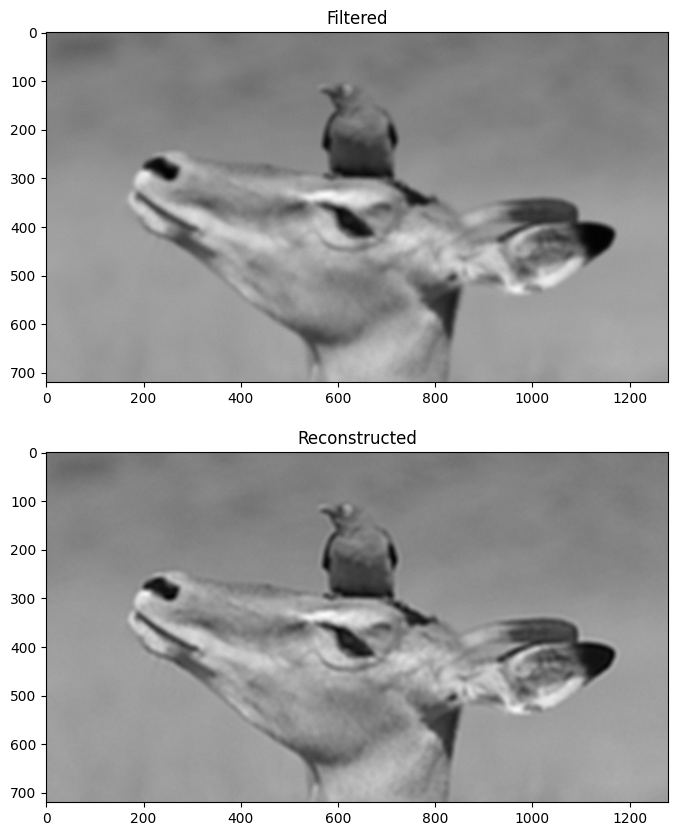

In [8]:
def landweber_iteration(y, filter_kernel, tau, num_iterations):
    """
    Landweber iteration for reverse filtering.

    Arguments
    ---------
    y : Observed (filtered) image
    filter_kernel : The filter kernel used for convolution
    tau : Step size for the update
    num_iterations : Number of iterations

    Returns
    -------
    x : Reconstructed image
    """
    # Initialize x as the observed image
    x = y.copy()

    # Precompute the adjoint filter (transpose of the kernel)
    adjoint_kernel = np.flip(filter_kernel)  # Transpose of convolution kernel

    for _ in range(num_iterations):
        # Apply the filter
        hx = cv2.filter2D(x, -1, filter_kernel)

        # Compute the residual
        residual = y - hx

        # Update x using the adjoint of the filter
        x += tau * cv2.filter2D(residual, -1, adjoint_kernel)

    return x

# Run the Landweber iterations
reconstructed = landweber_iteration(noisy_filtered, motion_blur, tau=0.1, num_iterations=50)

# Visualize results
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1); plt.title("Filtered"); plt.imshow(noisy_filtered, cmap='gray')
plt.subplot(2, 1, 2); plt.title("Reconstructed"); plt.imshow(reconstructed, cmap='gray')
plt.show()

### ✳︎ Total variation regularization

Total Variation (TV) regularization helps suppress noise while preserving edges. The regularized energy function adds a penalty term based on the gradient of the image:
$$
||f(x)-y||^2 + \gamma \int|\nabla x| \rightarrow \text{minimize}
$$
The following example implements the function.
>***Additional Argument***:
>>**`gamma`**
>>
>>A parameter controlling the strength of regularization
>>- Higher values prioritize noise suppression but can lead to overly smoothed images; lower values preserve detail but may leave noise
>
>***Variables***:
>>**`grad_x` and `grad_y`**
>>
>>The horizontal and vertical gradients of the current estimate.
>>- Represents changes in pixel intensity, capturing edges and textures
>
>>**`grad_magnitude`**
>>
>>The combined magnitude of the horizontal and vertical gradients
>>- Helps identify areas where edges or noise occur
>
>>**`tv_grad_x` and `tv_grad_y`**
>>
>>Gradients normalized by their magnitude
>>- Used to adjust `x` in a way that minimizes noise while preserving sharp transitions (e.g., edges)

### ✳︎ Phase correction

The **phase correction** scheme improves convergence by  correcting phase inconsistencies in the frequency domain. The updated rule becomes:
$$
X_{k+1} = X_{k} - \tau \frac{H^*}{|H|}(H X_{k} - Y)
$$
>*Variables*:
>>`X`:
>>- The Fourier transform of the current estimate `x`
>>- Transforms the image into the frequency domain; here, filtering operations are often simpler
>
>>`H`:
>>- The Fourier transform of the filter kernel
>>- Represents the frequency response of the filter
>
>>`HX`:
>>- The product of the filter's frequency response (`H`) and the image's Fourier transform (`X`)
>>- Represents the filtered image in the frequency domain
>
>>`correction`:
>>- The phase-corrected update applied in the frequency domain
>>- Ensures that updates are more accurate by aligning the phase of the Fourier components

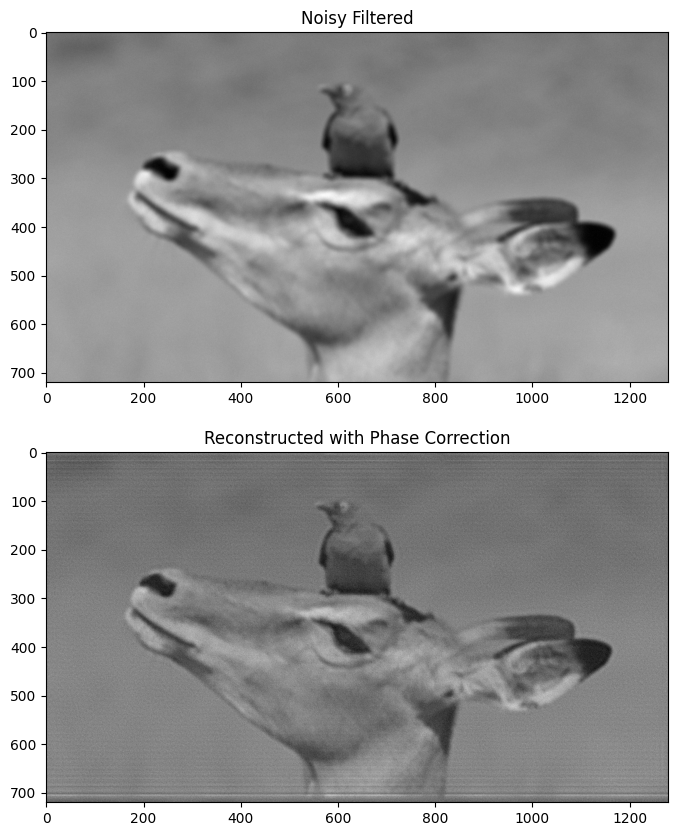

In [9]:
def landweber_phase_correction(y, filter_kernel, tau, num_iterations):
    """
    Landweber iteration with phase correction in the frequency domain
    """
    x = y.copy()
    adjoint_kernel = np.flip(filter_kernel)

    for _ in range(num_iterations):
        # Fourier transform of x and the kernel
        X = np.fft.fft2(x)
        H = np.fft.fft2(filter_kernel, s=x.shape)

        # Compute the residual in frequency domain
        HX = H * X
        Y = np.fft.fft2(y)
        residual_freq = Y - HX

        # Apply phase correction
        correction = np.conj(H) / (np.abs(H) + 1e-6) * residual_freq
        X += tau * correction

        # Inverse FFT to return to spatial domain
        x = np.fft.ifft2(X).real

    return x

# Run the phase correction method
reconstructed_phase = landweber_phase_correction(noisy_filtered, motion_blur, tau=0.1, num_iterations=50)

# Visualize results
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1); plt.title("Noisy Filtered"); plt.imshow(noisy_filtered, cmap='gray')
plt.subplot(2, 1, 2); plt.title("Reconstructed with Phase Correction"); plt.imshow(reconstructed_phase, cmap='gray')
plt.show()